In [1]:
import numpy as np
import matplotlib.pyplot as plt

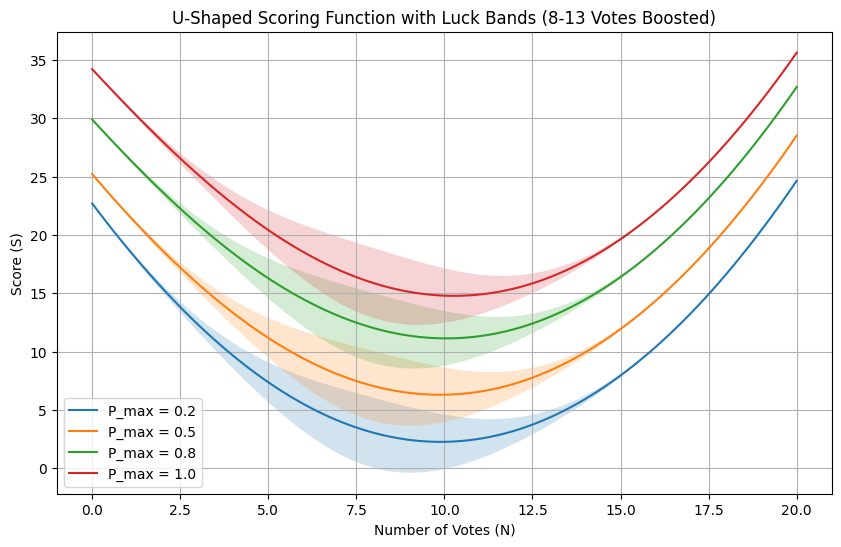

In [2]:
# Define parameters
alpha = 2      # Confidence influence in bootstrap
beta = 1        # Confidence influence in interest
lambda_ = 0.1   # Decay rate of bootstrap
mu = 0.2        # Growth rate of interest
gamma = 0.5     # Controls steepness of the U-shape
P_max_values = [0.2, 0.5, 0.8, 1.0]  # Different confidence levels for visualization
luck_magnitude = 3  # Max deviation for the bands
luck_peak_N = 8  # Peak of the luck effect in vote count
luck_width = 4   # Controls spread of the luck effect

# Define the function with only a U-shape adjustment, no extra boost beyond 13 votes
def score(N, P_max):
    S_B = 12 * (P_max ** alpha) * np.exp(-lambda_ * N)
    S_I = 12 * (1 - np.exp(-mu * N)) * (P_max ** beta)

    # U-shape adjustment (boosting low and high votes, penalizing mid-range)
    U_S = 8 * ((N - 10) / 6) ** 2

    return S_B + S_I + U_S

# Define the luck effect function (Gaussian-like peak around 5-12 votes)
def luck_effect(N):
    return luck_magnitude * np.exp(-((N - luck_peak_N) / luck_width) ** 2)

# Generate data points
N_values = np.linspace(0, 20, 100)  # Votes from 0 to 20

# Plot the function with bands for luck
plt.figure(figsize=(10, 6))

for P_max in P_max_values:
    scores = np.array([score(N, P_max) for N in N_values])

    # Compute the varying luck effect based on the vote count
    luck_variation = np.array([luck_effect(N) for N in N_values])

    # Compute luck bands (adding a small random variation around the main curve)
    lower_bound = scores - luck_variation
    upper_bound = scores + luck_variation

    # Plot the main score function
    plt.plot(N_values, scores, label=f"P_max = {P_max}")

    # Fill between for "luck bands" that peak between 5 and 12 votes
    plt.fill_between(N_values, lower_bound, upper_bound, alpha=0.2)

plt.xlabel("Number of Votes (N)")
plt.ylabel("Score (S)")
plt.title("U-Shaped Scoring Function with Luck Bands (8-13 Votes Boosted)")
plt.legend()
plt.grid(True)
plt.show()


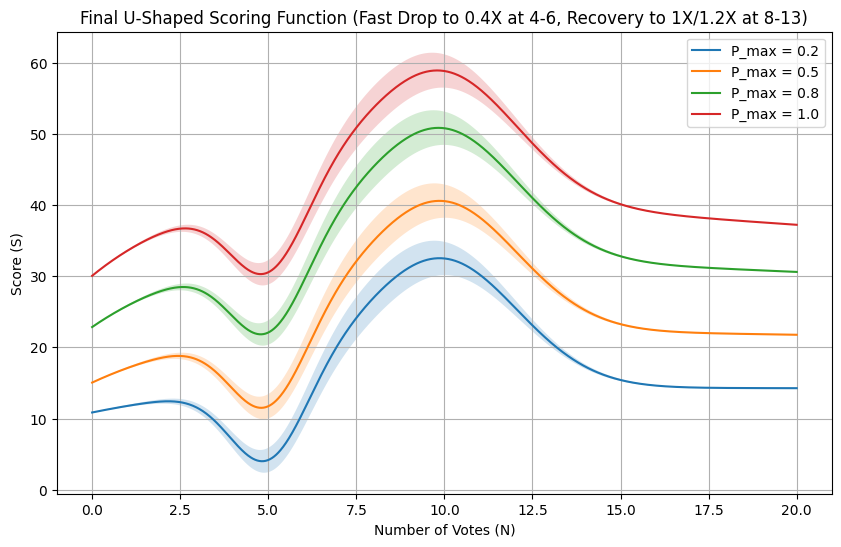

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
X = 20         # Initial starting score (adjustable)
alpha = 2      # Confidence influence in bootstrap
beta = 1       # Confidence influence in interest
lambda_ = 0.05 # Slower decay rate of bootstrap to keep higher initial scores
mu = 0.25      # Faster growth rate of interest-based score
L_max = 3      # Maximum luck effect
N_luck = 8     # Peak of the luck effect in vote count
sigma = 4      # Controls spread of the luck effect

offset = 10    # Prevent that function will return < 0 values

P_max_values = [0.2, 0.5, 0.8, 1.0]  # Different confidence levels for visualization

# Define the function with a true U-shape: min at 4-6 votes, rising by 8-13

def score(N, P_max):
    S_B = X * (P_max ** alpha) * np.exp(-lambda_ * N)  # High initial score, slow decay
    S_I = X * (1 - np.exp(-mu * N)) * (P_max ** beta)  # Low start, growing interest

    # U-shape adjustment: Fast drop to ~0.4X at 4-6, rise to 1X/1.2X at 8-13
    U_S = ((0.4 * X) - X) * np.exp(-((N - 5) / 1.5) ** 2) + ((1.2 * X) - 0.4 * X) * np.exp(-((N - 10) / 3) ** 2)

    # Luck effect: Maximum around N = 8, fades at extremes
    S_L = L_max * np.exp(-((N - N_luck) / sigma) ** 2)

    return S_B + S_I + U_S + S_L + offset

# Generate data points
N_values = np.linspace(0, 20, 1000)  # Votes from 0 to 20

# Plot the function with bands for luck
plt.figure(figsize=(10, 6))

for P_max in P_max_values:
    scores = np.array([score(N, P_max) for N in N_values])

    # Compute the varying luck effect based on the vote count
    luck_variation = np.array([L_max * np.exp(-((N - N_luck) / sigma) ** 2) for N in N_values])

    # Compute luck bands (adding a small random variation around the main curve)
    lower_bound = scores - luck_variation
    upper_bound = scores + luck_variation

    # Plot the main score function
    plt.plot(N_values, scores, label=f"P_max = {P_max}")

    # Fill between for "luck bands" that peak between 5 and 12 votes
    plt.fill_between(N_values, lower_bound, upper_bound, alpha=0.2)

plt.xlabel("Number of Votes (N)")
plt.ylabel("Score (S)")
plt.title("Final U-Shaped Scoring Function (Fast Drop to 0.4X at 4-6, Recovery to 1X/1.2X at 8-13)")
plt.legend()
plt.grid(True)
plt.show()


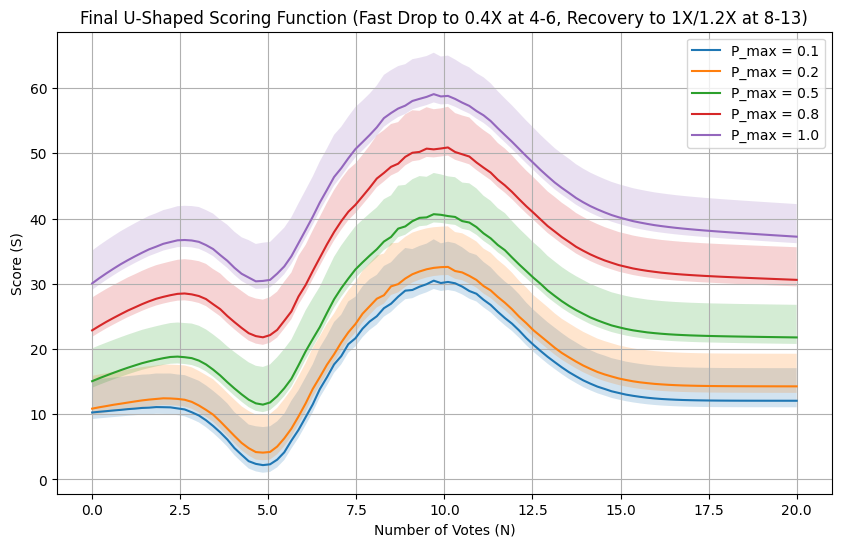

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import hashlib

# Define parameters
X = 20         # Initial starting score (adjustable)
alpha = 2      # Confidence influence in bootstrap
beta = 1       # Confidence influence in interest
lambda_ = 0.05 # Slower decay rate of bootstrap to keep higher initial scores
mu = 0.25      # Faster growth rate of interest-based score
L_max = 3      # Maximum luck effect
N_luck = 8     # Peak of the luck effect in vote count
sigma = 4      # Controls spread of the luck effect
offset = 10    # No negative values

P_max_values = [0.1, 0.2, 0.5, 0.8, 1.0]  # Different confidence levels for visualization

# Function to generate deterministic luck using hashing
def deterministic_luck(N, P_max):
    hash_input = f"{N}-{P_max}".encode()
    hash_value = int(hashlib.sha256(hash_input).hexdigest(), 16) % 1000  # Convert hash to int
    scaled_value = 0.9 + (hash_value / 1000) * 0.2  # Scale to range [0.9, 1.1]
    return (L_max * np.exp(-((N - N_luck) / sigma) ** 2) * scaled_value) + offset  # Offset to avoid negative values

# Define the function with a true U-shape: min at 4-6 votes, rising by 8-13
def score(N, P_max):
    S_B = X * (P_max ** alpha) * np.exp(-lambda_ * N)  # High initial score, slow decay
    S_I = X * (1 - np.exp(-mu * N)) * (P_max ** beta)  # Low start, growing interest

    # U-shape adjustment: Fast drop to ~0.4X at 4-6, rise to 1X/1.2X at 8-13
    U_S = ((0.4 * X) - X) * np.exp(-((N - 5) / 1.5) ** 2) + ((1.2 * X) - 0.4 * X) * np.exp(-((N - 10) / 3) ** 2)

    # Deterministic Luck effect
    S_L = deterministic_luck(N, P_max)

    return S_B + S_I + U_S + S_L

# Generate data points
N_values = np.linspace(0, 20, 100)  # Votes from 0 to 20

# Plot the function with bands for luck
plt.figure(figsize=(10, 6))

for P_max in P_max_values:
    scores = np.array([score(N, P_max) for N in N_values])

    # Compute the varying luck effect based on the vote count
    luck_variation = np.array([deterministic_luck(N, P_max) for N in N_values])

    # Compute luck bands (adding a small deterministic variation around the main curve)
    lower_bound = scores - 0.1*luck_variation
    upper_bound = scores + 0.5*luck_variation

    # Plot the main score function
    plt.plot(N_values, scores, label=f"P_max = {P_max}")

    # Fill between for "luck bands" that peak between 5 and 12 votes
    plt.fill_between(N_values, lower_bound, upper_bound, alpha=0.2)

plt.xlabel("Number of Votes (N)")
plt.ylabel("Score (S)")
plt.title("Final U-Shaped Scoring Function (Fast Drop to 0.4X at 4-6, Recovery to 1X/1.2X at 8-13)")
plt.legend()
plt.grid(True)
plt.show()

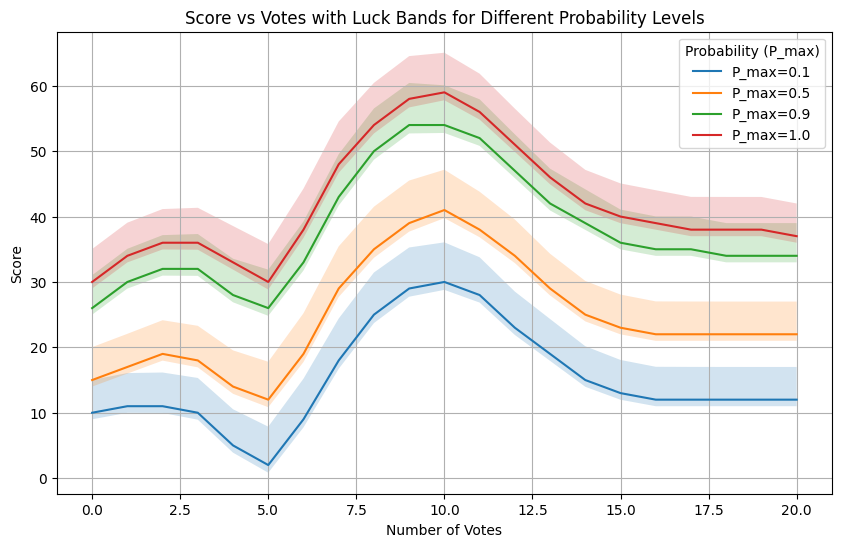

In [5]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define scoring function parameters
X = 20  # Initial starting score
alpha = 2  # Confidence influence in bootstrap
beta = 1  # Confidence influence in interest
lambda_ = 0.05  # Slower decay rate of bootstrap to keep higher initial scores
mu = 0.25  # Faster growth rate of interest-based score
L_max = 3  # Maximum luck effect
N_luck = 8  # Peak of the luck effect in vote count
sigma = 4  # Controls spread of the luck effect
offset = 10  # Ensures non-negative values

def deterministic_luck(N: int, P_max: float) -> float:
    """
    Generates deterministic luck using hashing, ensuring varied but consistent luck effects.

    Args:
        N (int): Number of votes.
        P_max (float): Maximum confidence value in votes.

    Returns:
        float: Luck-based adjustment factor.
    """
    hash_input = f"{N}-{P_max}".encode()
    hash_value = int(hashlib.sha256(hash_input).hexdigest(), 16) % 1000  # Convert hash to int
    scaled_value = 0.9 + (hash_value / 1000) * 0.2  # Scale to range [0.9, 1.1]
    return (L_max * np.exp(-((N - N_luck) / sigma) ** 2) * scaled_value) + offset  # Offset avoids negative values

def score(N: int, P_max: float) -> int:
    """
    Computes a dynamic score for SDG user labels based on voting behavior.

    Args:
        N (int): Number of votes cast.
        P_max (float): Maximum probability confidence of votes.

    Returns:
        int: Computed score.
    """
    S_B = X * (P_max ** alpha) * np.exp(-lambda_ * N)  # Initial confidence, slow decay
    S_I = X * (1 - np.exp(-mu * N)) * (P_max ** beta)  # Interest-based scoring

    # U-shape adjustment: Fast drop at 4-6 votes, rises again at 8-13
    U_S = ((0.4 * X) - X) * np.exp(-((N - 5) / 1.5) ** 2) + ((1.2 * X) - 0.4 * X) * np.exp(-((N - 10) / 3) ** 2)

    # Apply deterministic luck effect
    S_L = deterministic_luck(N, P_max)

    return max(round(S_B + S_I + U_S + S_L), 0)

# Define vote counts and probabilities
vote_counts = np.arange(0, 21)  # Votes from 0 to 20
probabilities = [0.1, 0.5, 0.9, 1.0]

# Function to calculate scores based on the provided probability and vote count
def calculate_scores(votes, probability):
    return [score(vote, probability) for vote in votes]

# Set up the plot
plt.figure(figsize=(10, 6))

# Plot the scores for different probabilities with luck bands
for p in probabilities:
    scores = calculate_scores(vote_counts, p)

    # Luck variation factor
    luck_variation = [deterministic_luck(vote, p) for vote in vote_counts]

    # Compute luck bands (adding a small deterministic variation around the main curve)
    lower_bound = np.array(scores) - 0.1 * np.array(luck_variation)
    upper_bound = np.array(scores) + 0.5 * np.array(luck_variation)

    # Plot the score line
    sns.lineplot(x=vote_counts, y=scores, label=f'P_max={p}')

    # Plot the luck bands (shaded region)
    plt.fill_between(vote_counts, lower_bound, upper_bound, alpha=0.2)

# Add labels and title
plt.title("Score vs Votes with Luck Bands for Different Probability Levels")
plt.xlabel("Number of Votes")
plt.ylabel("Score")
plt.legend(title="Probability (P_max)")
plt.grid(True)
plt.savefig("scores.pdf")
plt.show()


In [8]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Your existing imports and calculations remain unchanged...

# Set up the plot with publication-ready styling
plt.style.use('seaborn-v0_8-whitegrid')  # Clean, professional style
plt.figure(figsize=(10, 6))

# Use perceptually uniform colors from the 'rocket' palette
# This is ideal for showing progression and relationships
colors = sns.color_palette("colorblind", n_colors=len(probabilities))

# Plot the scores for different probabilities with luck bands
for i, p in enumerate(probabilities):
    scores = calculate_scores(vote_counts, p)
    luck_variation = [deterministic_luck(vote, p) for vote in vote_counts]

    # Calculate bounds for luck bands
    lower_bound = np.array(scores) - 0.1 * np.array(luck_variation)
    upper_bound = np.array(scores) + 0.5 * np.array(luck_variation)

    # Plot the score line with publication-appropriate linewidth
    sns.lineplot(
        x=vote_counts,
        y=scores,
        color=colors[i],
        linewidth=2,
        label=f'P_max={p}'
    )

    # Plot the luck bands with reduced opacity
    plt.fill_between(
        vote_counts,
        lower_bound,
        upper_bound,
        color=colors[i],
        alpha=0.15
    )

# Enhance the plot for publication quality
plt.title("Score vs Votes with Luck Bands for Different Probability Levels",
          pad=20, fontsize=12, fontweight='bold')

# Use serif fonts for publication compatibility
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

# Adjust layout for clarity
plt.xlabel("Number of Votes", fontsize=10)
plt.ylabel("Score", fontsize=10)
plt.legend(title="Probability (P_max)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

# Ensure proper spacing
plt.tight_layout()

# Save with high DPI for publication quality
plt.savefig("scores.pdf", dpi=600, bbox_inches='tight')
plt.close()